In [1]:
#%config InlineBackend.figure_formats=['svg']
# Generic import 
import numpy as np
from os import listdir
import matplotlib.pyplot as plt
# Train a model
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results
from AutoencoderAPI.loadAutoencoder import plot_weigths
# Define clustering
from AutoencoderAPI.autoencoderGaussianMixture import autoencoder_gaussianMixture

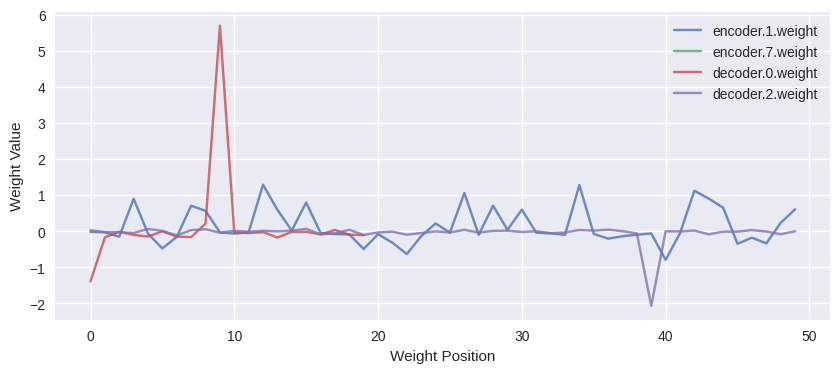

In [2]:
plot_weigths('AutoencoderLog/grid-search-SPSPD param (dropout with zero photon)/run 06/fold 0')

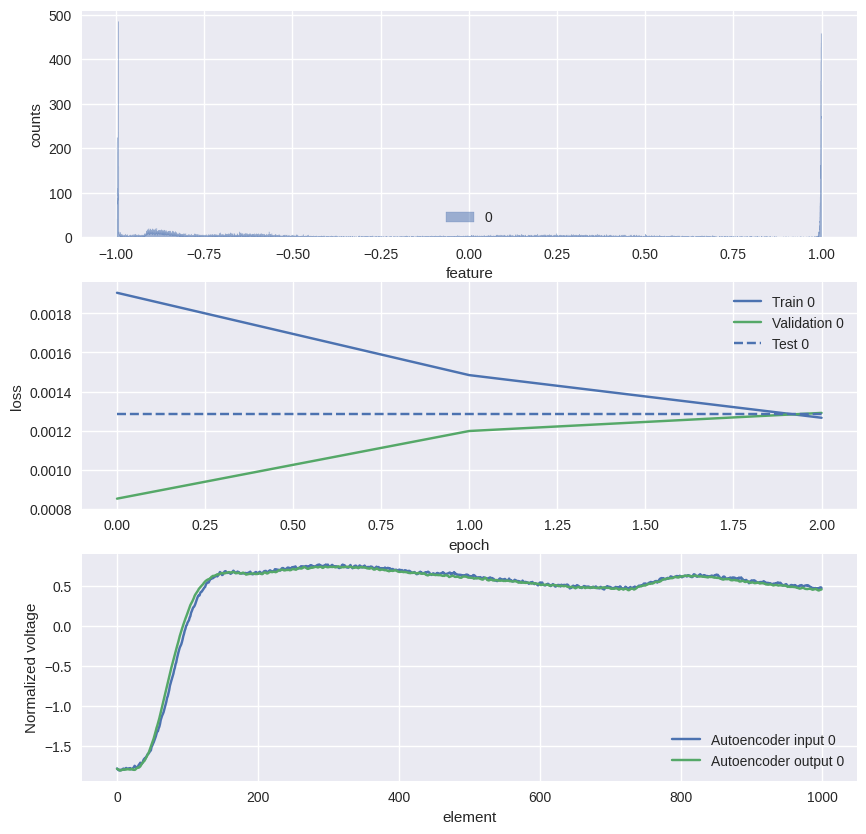

In [4]:
load_run_results('AutoencoderLog/grid-search-SNSPD Triplet/run 00')

min :  0.0005979607808928266
learning_rate_triplet :  1e-05
alpha :  1.0
[0.0012846703254200279, 0.0006226960079566699, 0.0005979607808928266, 0.0006010761784908522, 0.0030684637280398103]


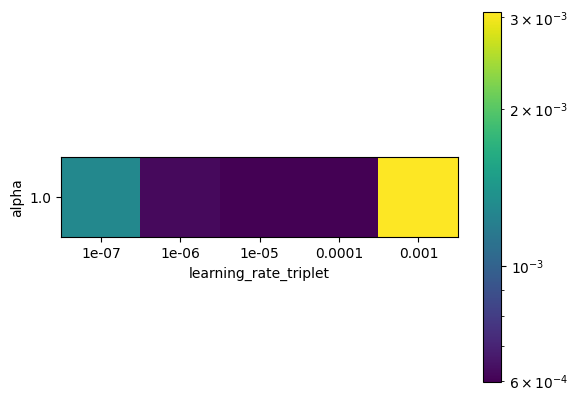

In [6]:
load_sweep_results("grid-search-SNSPD Triplet", ["learning_rate_triplet", "alpha"])

In [15]:
from AutoencoderAPI.utils.files import load_mean_std
import numpy as np
from os import listdir

signal_size = 30_000
path_test = 'Datasets/SNSPD/Paderborn/data/'
path_train = 'Datasets/SNSPD/Paderborn/data1/'
path_model = 'run-2024-01-06-12-21/fold 0'
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::4, 3250:4500] for fileName in listdir(path_test)[::2]])
#X_train = np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::4, 3250:4500] for fileName in listdir(path_train)[::2]])

X_test = (X_test - mean)/std
#X_train = (X_train - mean)/std

X_test = X_test[np.min(X_test, axis=1) < -0.5]
X_test = X_test[np.max(X_test, axis=1) > 1.75]
X_test = X_test[np.argmax(X_test, axis=1) < 50]

-10153.858890977777 16902.639283052387


FileNotFoundError: [Errno 2] No such file or directory: 'Datasets/SNSPD/Paderborn/data/'

In [ ]:
from AutoencoderAPI.encoderStack import encoderStack

es = encoderStack()
X, labels = es.stack(X_test, "AutoencoderLog/testStack")

TypeError: masked_select(): argument 'input' (position 1) must be Tensor, not numpy.ndarray